In [13]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
numeric_columns_data = df.select_dtypes(include=['number'])
numeric_columns_data.corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [11]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


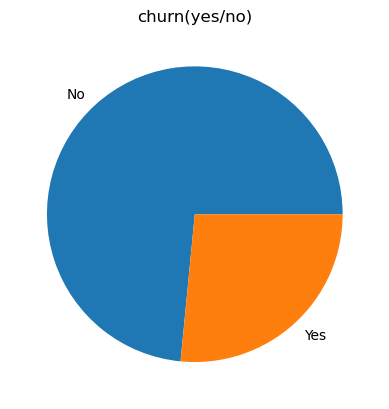

In [15]:
df["Churn"].value_counts().plot(kind="pie")
plt.title("churn(yes/no)")
plt.ylabel("")
plt.show()

In [17]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [20]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [22]:
df.groupby(["Churn","gender"])["MonthlyCharges"].mean()

Churn  gender
No     Female    61.664908
       Male      60.876914
Yes    Female    74.812087
       Male      74.066989
Name: MonthlyCharges, dtype: float64

In [24]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

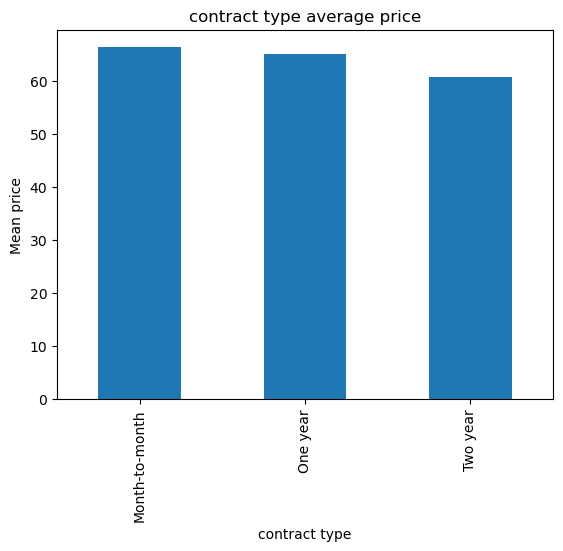

In [27]:
df.groupby("Contract")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("Mean price")
plt.xlabel("contract type")
plt.title("contract type average price")
plt.show

In [28]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


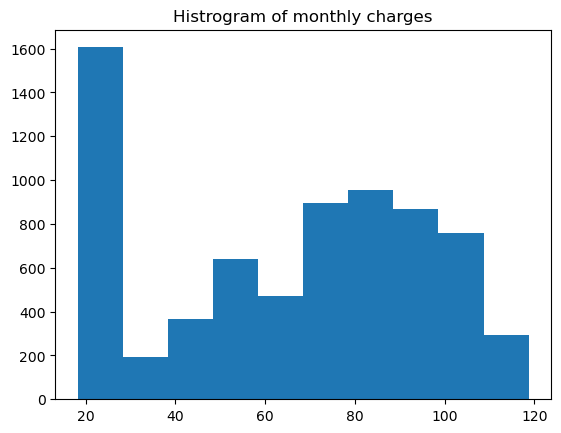

In [30]:
plt.hist(df["MonthlyCharges"])
plt.title("Histrogram of monthly charges")
plt.show()

Text(0.5, 1.0, 'Histogram of tenure')

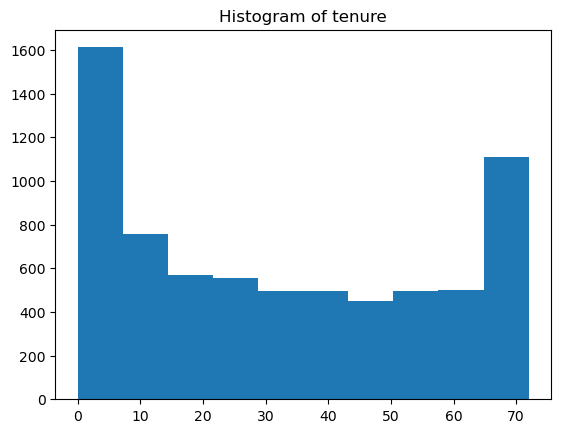

In [31]:
plt.hist(df["tenure"])
plt.title("Histogram of tenure")

In [32]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [37]:
y = df[["Churn"]]
X = df[["PhoneService","gender","tenure","MonthlyCharges"]]

In [38]:
y

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [39]:
X # 1 for female and 0 for male

,PhoneService,gender,tenure,MonthlyCharges
0,No,Female,1,29.85
1,Yes,Male,34,56.95
2,Yes,Male,2,53.85
3,No,Male,45,42.30
4,Yes,Female,2,70.70
...,...,...,...,...
7038,Yes,Male,24,84.80
7039,Yes,Female,72,103.20
7040,No,Female,11,29.60
7041,Yes,Male,4,74.40


In [40]:
X["gender"].apply(lambda x: 1 if x == "Female" else 0)

0       1
1       0
2       0
3       0
4       1
       ..
7038    0
7039    1
7040    1
7041    0
7042    0
Name: gender, Length: 7043, dtype: int64

In [42]:
type(X["gender"][0])

str

In [43]:
y["Churn"] = y["Churn"].apply(lambda x: 1 if x =="Yes" else 0)

/var/folders/sr/gpy0d9693gs3vn4x1wg48k6w0000gn/T/ipykernel_5104/1807528793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"] = y["Churn"].apply(lambda x: 1 if x =="Yes" else 0)


In [44]:
y["Churn"][0]

np.int64(0)

In [45]:
X

,PhoneService,gender,tenure,MonthlyCharges
0,No,Female,1,29.85
1,Yes,Male,34,56.95
2,Yes,Male,2,53.85
3,No,Male,45,42.30
4,Yes,Female,2,70.70
...,...,...,...,...
7038,Yes,Male,24,84.80
7039,Yes,Female,72,103.20
7040,No,Female,11,29.60
7041,Yes,Male,4,74.40


In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train , y_test = train_test_split(X,y, test_size = 0.2)

In [47]:
X

,PhoneService,gender,tenure,MonthlyCharges
0,No,Female,1,29.85
1,Yes,Male,34,56.95
2,Yes,Male,2,53.85
3,No,Male,45,42.30
4,Yes,Female,2,70.70
...,...,...,...,...
7038,Yes,Male,24,84.80
7039,Yes,Female,72,103.20
7040,No,Female,11,29.60
7041,Yes,Male,4,74.40


In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

In [51]:
y = df["Churn"] 

In [52]:
y = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
print(X_train.dtypes)

PhoneService       object
gender             object
tenure              int64
MonthlyCharges    float64
dtype: object


In [ ]:
X = df[["gender", "tenure", "MonthlyCharges"]]

X = pd.get_dummies(X, drop_first=True)

y = df["Churn"].map({"Yes": 1, "No": 0})

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.dtypes)


tenure              int64
MonthlyCharges    float64
gender_Male          bool
dtype: object


In [62]:
X_train = scaler.fit_transform(X_train)

In [63]:
import joblib
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [64]:
X_test = scaler.fit_transform(X_test)

In [65]:
X_test

array([[-1.24994972, -1.31446753, -0.94946537],
       [ 0.34420217, -1.29951212,  1.05322431],
       [ 0.78259394, -1.49559418, -0.94946537],
       ...,
       [-0.61228897, -1.47731534,  1.05322431],
       [ 1.4601085 , -0.67803171, -0.94946537],
       [-1.24994972, -1.09678322,  1.05322431]])

In [66]:
X_train

array([[-4.65683364e-01, -4.73723375e-04, -1.02516569e+00],
       [ 8.85536787e-01,  1.07475386e+00, -1.02516569e+00],
       [-1.28460467e+00, -1.37649913e+00,  9.75452077e-01],
       ...,
       [-8.34197950e-01, -1.45294499e+00,  9.75452077e-01],
       [-8.34197950e-01,  1.14953785e+00,  9.75452077e-01],
       [-2.60953038e-01, -1.49781538e+00,  9.75452077e-01]])

In [68]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions): 
    print("Accuracy score on model is{}".format(accuracy_score(y_test, predictions)))

In [69]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.linear_model import LogisticRegression

In [76]:
log_model = LogisticRegression()

In [73]:
import warnings 
warnings.filterwarnings("ignore")

In [77]:
log_model.fit(X_train, y_train)

LogisticRegression()

In [81]:
log_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [84]:
y_pred = log_model.predict(X_test)

In [85]:
y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

In [86]:
modelperformance(y_pred)

Accuracy score on model is0.7970191625266146


In [87]:
from sklearn.neighbors import KNeighborsClassifier

In [88]:
param_grid = {
    "n_neighbors" : [3,5,7,9],
    "weights" : ["uniform","distance"],
}

In [89]:
gridkn = GridSearchCV(KNeighborsClassifier(),param_grid, cv = 5)
gridkn.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [90]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [91]:
y_pred = gridkn.predict(X_test)

In [92]:
modelperformance(y_pred)

Accuracy score on model is0.7913413768630234


In [94]:
from sklearn.svm import SVC

In [96]:
svm = SVC()

In [99]:
param_grid = {
    "C" : [0.01,0.2,0.5,1],
    "kernel" : ["Linear","rbf","poly"]
}

In [101]:
gridsvc = GridSearchCV(svm, param_grid, cv = 5)

In [102]:
gridsvc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.2, 0.5, 1],
                         'kernel': ['Linear', 'rbf', 'poly']})

In [103]:
gridsvc.best_params_

{'C': 0.2, 'kernel': 'poly'}

In [105]:
y_pred = gridsvc.predict(X_test)

In [106]:
modelperformance(y_pred)

Accuracy score on model is0.7970191625266146


In [107]:
from sklearn.tree import DecisionTreeClassifier

In [108]:
param_grid = {
    "criterion" : ["gini","entropy"],
    "splitter" : ["best","random"],
    "max_depth" : [None, 10, 20, 30],
    "min_samples_split" : [2, 5 , 10],
    "min_samples_leaf" : [1,2,4]
}

In [109]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)

In [111]:
y_pred = grid_tree.fit(X_train,y_train)

In [115]:
y_pred = grid_tree.best_estimator_.predict(X_test)

In [116]:
modelperformance(y_pred)

Accuracy score on model is0.7672107877927609


In [117]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [122]:
param_grid = {
    "n_estimators" : [32,64,128,256],
    "max_features" : [2,3,4],
    "bootstrap" : [True,False]
}

In [124]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv = 5)

In [125]:
grid_rfc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [126]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 256}

In [127]:
y_pred = grid_rfc.predict(X_test)

In [128]:
modelperformance(y_pred)

Accuracy score on model is0.7551454932576295


In [129]:
best_model = gridsvc.best_estimator_

In [130]:
joblib.dump(best_model,"model.pkl")

['model.pkl']

In [132]:
X.columns

Index(['tenure', 'MonthlyCharges', 'gender_Male'], dtype='object')